# Day 2 · 线性回归——手写梯度下降

> 目标：理解 模型 = 参数 + 损失函数 + 优化器 这个公式

## 0. 导入三板斧

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
print("Day 2 开始!")

Day 2 开始!


## 1. 生成假数据

真实关系:  = 3x + 2 + 	ext{噪声}$

我们就用这个来验证：梯度下降能不能从数据里找回 =3, b=2$？

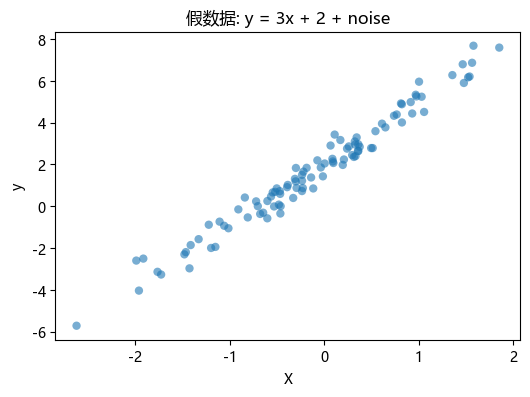

X shape: (100, 1), y shape: (100,)


In [3]:
np.random.seed(42)
X = np.random.randn(100, 1)           # 100个样本, 1个特征
true_w, true_b = 3.0, 2.0
y = true_w * X.squeeze() + true_b + np.random.randn(100) * 0.5  # 加噪声

plt.figure(figsize=(6, 4))
plt.scatter(X, y, alpha=0.6, edgecolors="none")
plt.xlabel("X"); plt.ylabel("y")
plt.title("假数据: y = 3x + 2 + noise")
plt.show()
print(f"X shape: {X.shape}, y shape: {y.shape}")

## 2. 前向传播：从参数到预测

552\hat{y} = wx + b552

最简单的一元线性模型：一个权重 $，一个偏置 $。

In [6]:
def predict(X, w, b):
    return w * X.squeeze() + b

def mse_loss(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean()

# 随便猜一组参数
w_random, b_random = np.random.randn(), np.random.randn()
y_guess = predict(X, w_random, b_random)
print(f"随机参数: w={w_random:.3f}, b={b_random:.3f}")
print(f"随机猜测的损失: {mse_loss(y_guess, y):.3f}")

随机参数: w=-1.378, b=-0.938
随机猜测的损失: 21.583


## 3. 梯度下降 —— 核心！

损失函数: 552J(w,b) = 
rac{1}{m}\sum_{i=1}^{m}(wx_i + b - y_i)^2552

梯度（偏导数）:

552
rac{\partial J}{\partial w} = 
rac{2}{m}\sum_{i=1}^{m} x_i(wx_i + b - y_i)552

552
rac{\partial J}{\partial b} = 
rac{2}{m}\sum_{i=1}^{m} (wx_i + b - y_i)552

更新公式:

552w := w - lpha \cdot 
rac{\partial J}{\partial w}552

552b := b - lpha \cdot 
rac{\partial J}{\partial b}552

In [7]:
# 初始化
w = np.random.randn()
b = np.random.randn()
lr = 0.01      # 学习率
epochs = 2000  # 迭代次数
losses = []

m = len(y)
for epoch in range(epochs):
    # 前向: 预测
    y_pred = w * X.squeeze() + b
    
    # 算损失
    loss = ((y_pred - y) ** 2).mean()
    losses.append(loss)
    
    # 反向: 手算梯度
    dw = (2 / m) * (X.squeeze() * (y_pred - y)).sum()
    db = (2 / m) * (y_pred - y).sum()
    
    # 更新参数
    w -= lr * dw
    b -= lr * db
    
    if epoch % 300 == 0:
        print(f"Epoch {epoch:4d}: w={w:.3f}, b={b:.3f}, loss={loss:.4f}")

print(f"真实: w={true_w}, b={true_b}")
print(f"学得: w={w:.3f}, b={b:.3f}")

Epoch    0: w=0.552, b=0.539, loss=6.5124
Epoch  300: w=2.906, b=1.993, loss=0.2214
Epoch  600: w=2.928, b=2.004, loss=0.2209
Epoch  900: w=2.928, b=2.004, loss=0.2209
Epoch 1200: w=2.928, b=2.004, loss=0.2209
Epoch 1500: w=2.928, b=2.004, loss=0.2209
Epoch 1800: w=2.928, b=2.004, loss=0.2209
真实: w=3.0, b=2.0
学得: w=2.928, b=2.004


## 4. 可视化：损失曲线 + 拟合直线

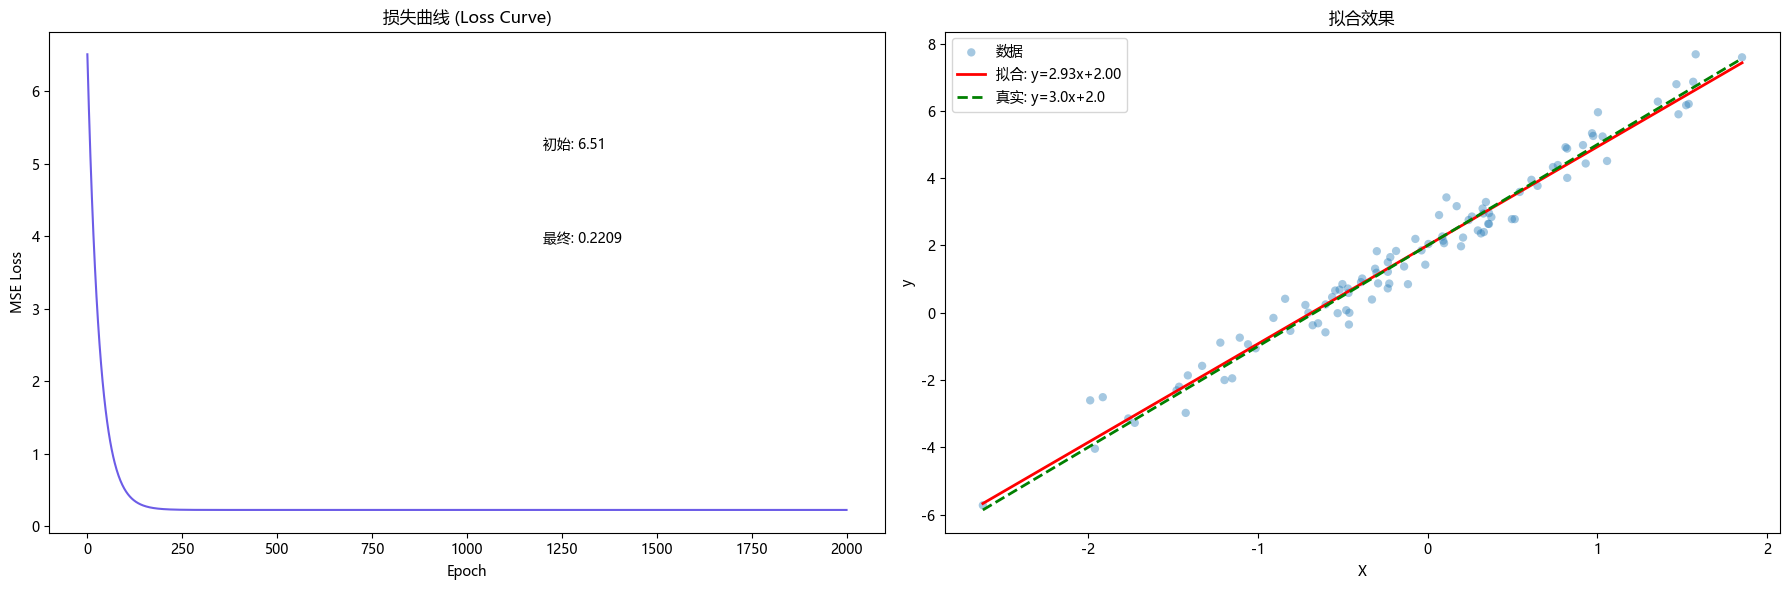

✅ 如果红色实线和绿色虚线几乎重合, 说明梯度下降成功了!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 损失曲线 —— 应该一直下降
axes[0].plot(losses, color="#6c5ce7")
axes[0].set_title("损失曲线 (Loss Curve)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].text(epochs*0.6, losses[0]*0.8, f"初始: {losses[0]:.2f}", fontsize=10)
axes[0].text(epochs*0.6, losses[0]*0.6, f"最终: {losses[-1]:.4f}", fontsize=10)

# 拟合直线
axes[1].scatter(X, y, alpha=0.4, label="数据", edgecolors="none")
x_line = np.linspace(X.min(), X.max(), 100)
axes[1].plot(x_line, w * x_line + b, "r-", linewidth=2, label=f"拟合: y={w:.2f}x+{b:.2f}")
axes[1].plot(x_line, true_w * x_line + true_b, "g--", linewidth=2, label=f"真实: y={true_w}x+{true_b}")
axes[1].set_xlabel("X"); axes[1].set_ylabel("y")
axes[1].set_title("拟合效果"); axes[1].legend()

plt.tight_layout()
plt.savefig("day2_linear_regression.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ 如果红色实线和绿色虚线几乎重合, 说明梯度下降成功了!")

## 5. 🧪 实验：学习率的影响

分别试 **0.001 / 0.01 / 0.1 / 1.0**，看损失曲线会怎样？

d:\anaconda\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
D:\hyy\Temp\ipykernel_31348\2994578369.py:25: RuntimeWarning: overflow encountered in square
  loss_history.append(((y_pred - y)**2).mean())
d:\anaconda\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
D:\hyy\Temp\ipykernel_31348\2994578369.py:28: RuntimeWarning: invalid value encountered in scalar subtract
  w_t -= lr * dw; b_t -= lr * db
D:\hyy\Temp\ipykernel_31348\2994578369.py:43: RuntimeWarning: invalid value encountered in scalar subtract
  w_t -= lr * dw; b_t -= lr * db


图片已保存至: d:\hyy\Desktop\c++\python深度学习\Week1\Day2\learning_rate_comparison.png


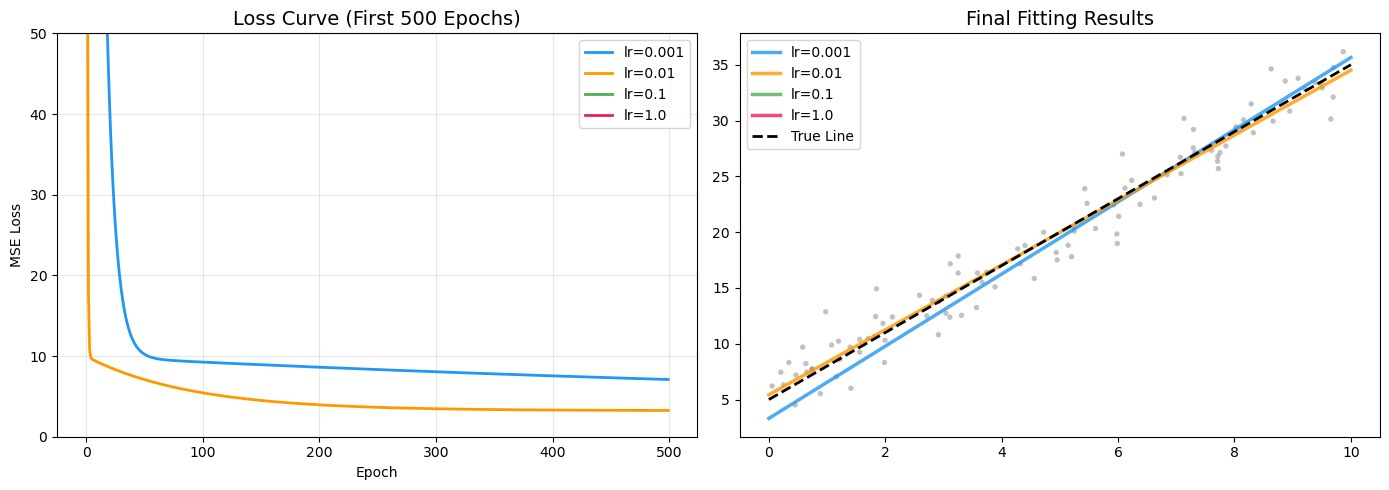

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os  # 1. 导入系统操作模块

# --- 模拟数据生成 (保持你原有的逻辑) ---
np.random.seed(42)
X = np.random.rand(100, 1) * 10
true_w, true_b = 3.0, 5.0
y = true_w * X.squeeze() + true_b + np.random.randn(100) * 2
m = len(y)
x_line = np.linspace(0, 10, 100)

# 2. 定义高可视性配色与学习率
lrs = [0.001, 0.01, 0.1, 1.0]
colors = ["#2196F3", "#FF9800", "#4CAF50", "#E91E63"] 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左图：损失曲线 ---
for lr, c in zip(lrs, colors):
    w_t, b_t = 0.0, 0.0 
    loss_history = []
    for epoch in range(500):
        y_pred = w_t * X.squeeze() + b_t
        loss_history.append(((y_pred - y)**2).mean())
        dw = (2/m) * (X.squeeze() * (y_pred - y)).sum()
        db = (2/m) * (y_pred - y).sum()
        w_t -= lr * dw; b_t -= lr * db
    axes[0].plot(loss_history, color=c, label=f"lr={lr}", linewidth=2)

axes[0].set_title("Loss Curve (First 500 Epochs)", fontsize=14)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 50) # 限制Y轴，让曲线对比更明显

# --- 右图：拟合结果 ---
for lr, c in zip(lrs, colors):
    w_t, b_t = 0.0, 0.0
    for _ in range(1500):
        y_pred = w_t * X.squeeze() + b_t
        dw = (2/m) * (X.squeeze() * (y_pred - y)).sum()
        db = (2/m) * (y_pred - y).sum()
        w_t -= lr * dw; b_t -= lr * db
    
    # 绘制最终拟合线
    axes[1].plot(x_line, w_t * x_line + b_t, color=c, linewidth=2.5, alpha=0.8, label=f"lr={lr}")

# 绘制原始数据点和真实直线
axes[1].scatter(X, y, alpha=0.3, edgecolors="none", s=15, color="#333333")
axes[1].plot(x_line, true_w * x_line + true_b, "k--", linewidth=2, label="True Line")

axes[1].set_title("Final Fitting Results", fontsize=14)
axes[1].legend(fontsize=10)

plt.tight_layout()

# ==========================================
# 🔥 3. 自动保存到代码所在文件夹的逻辑
# ==========================================
# 获取当前脚本所在的绝对路径
import os

# --- 修改部分开始 ---

# 1. 直接获取当前的“工作目录”（在 Notebook 中这通常就是文件所在的文件夹）
script_dir = os.getcwd()

# 2. 拼接文件名
save_path = os.path.join(script_dir, "learning_rate_comparison.png")

# --- 修改部分结束 ---

# 3. 保存图片
plt.savefig(save_path, dpi=150, bbox_inches='tight')

# 4. (可选) 打印一下路径，确认保存到了哪里
print(f"图片已保存至: {save_path}")

plt.show()

## 6. 用 sklearn 验证我们的结果

手写完再用 sklearn 跑一遍，对比参数。

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)  # sklearn 内部自动做梯度下降

print("=== 参数对比 ===")
print(f"真实参数:     w={true_w}, b={true_b}")
print(f"我们手写的:    w={w:.4f}, b={b:.4f}")
print(f"sklearn:       w={model.coef_[0]:.4f}, b={model.intercept_:.4f}")

# R² 分数
print(f"sklearn R²: {model.score(X, y):.4f}  (1.0 = 完美拟合)")

=== 参数对比 ===
真实参数:     w=3.0, b=5.0
我们手写的:    w=2.9284, b=2.0037
sklearn:       w=2.9080, b=5.4302
sklearn R²: 0.9583  (1.0 = 完美拟合)


# 🎉 Day 2 完成！

## 今天学到的

| 概念 | 一句话 |
|------|--------|
| **前向传播** | 输入 X → wx+b → 预测值 |
| **损失函数** | MSE: 平均(预测-真实)² |
| **梯度** | 偏导数 ∂J/∂w, ∂J/∂b — 指向损失上升最快的方向 |
| **梯度下降** | 沿梯度**反方向**走一小步，反复直到最低点 |
| **学习率** | 每步的大小——太小收敛慢，太大发散 |

## 模型 = 参数 + 损失函数 + 优化器



## 晚上作业

1. 把学习率改成 0.003 / 0.03 / 0.3 / 3.0，重新跑一遍实验
2. 试着手推 ∂J/∂w 的公式（在纸上），再对照代码
3. 预习：逻辑回归的 Sigmoid 函数长什么样？
